In the name of God

# LLM Course - Computer Assignment 1

* I wrote the answers in English so I could later on (when there is internet!) upload the code to github!

In this notebook we are going to implement a simple LM from scratch. We will do so by using the transformer architecture shown in the image below. The goal is to train a decoder only model that is trained on a dataset of names and learns to predict the name based on the first few characters. 

![transformer model.png](<attachment:transformer model.png>)
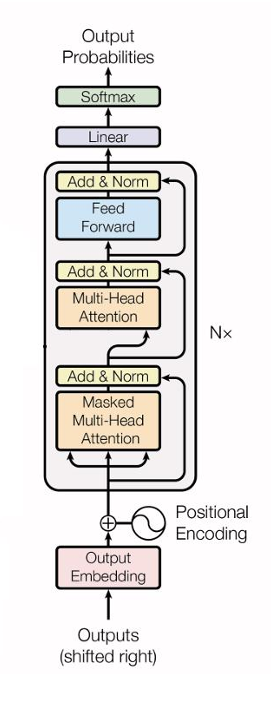

## 1. Data Preparation & Tokenization

In this section we are going to take a look at our dataset, preprocess it, build the vocabulary and convert the dataset to pytorch tensors that are later going to be used for training.

### 1.1. Loading & Preprocessing the Data

In this section we will load the dataset, take a look at its structure and perform some data cleaning.

In [57]:
import pandas as pd

names_df = pd.read_csv("Names.csv")

names_df

,Id,Name,Year,Gender,Count
0,1,Mary,1880,F,7065
1,2,Anna,1880,F,2604
2,3,Emma,1880,F,2003
3,4,Elizabeth,1880,F,1939
4,5,Minnie,1880,F,1746
...,...,...,...,...,...
1825428,1825429,Zykeem,2014,M,5
1825429,1825430,Zymeer,2014,M,5
1825430,1825431,Zymiere,2014,M,5
1825431,1825432,Zyran,2014,M,5


In [58]:
names_df["Name"].value_counts()

Name
Jessie      270
Ollie       270
Jesse       270
Tommie      270
Johnnie     270
           ... 
Zeidan        1
Shmeil        1
Shreehan      1
Shriyaan      1
Sidahmed      1
Name: count, Length: 93889, dtype: int64

As we can see, we have a lot of duplicated names in our dataset. Since we don't want the mode to be biased towards the more popular names, we will remove them. 

We also only need the names so we shall remove all the extra stuff.

In [59]:
names = set(names_df["Name"])

print(names)

{'Andrewmichael', 'Jaabir', 'Louria', 'Skeeter', 'Shebra', 'Praveer', 'Zymire', 'Brionica', 'Karlyee', 'Xiomy', 'Toshiba', 'Pinchus', 'Davaney', 'Dnielle', 'Rahkia', 'Tallulah', 'Kaiona', 'Dasa', 'Kysha', 'Lenix', 'Jimetta', 'Sohela', 'Dereona', 'Ange', 'Quentina', 'Nicolemarie', 'Ammie', 'Quanell', 'Iram', 'Seslie', 'Alexiana', 'Brailon', 'Lakera', 'Hyden', 'Liddie', 'Kenisha', 'Noma', 'Bernt', 'Ayante', 'Jenitha', 'Reshonda', 'Latavea', 'Beauford', 'Aalexus', 'Syliss', 'Decklen', 'Skylier', 'Tysheka', 'Winslow', 'Meghean', 'Diesha', 'Terriek', 'Elysia', 'Soraide', 'Kynesha', 'Champagne', 'Lundon', 'Aylssa', 'Steffane', 'Sarosh', 'Jaycey', 'Aleema', 'Arnel', 'Donielle', 'Jermiyah', 'Camyron', 'Jyme', 'Taggert', 'Keica', 'Dawnta', 'Jizzel', 'Kerstie', 'Enriquez', 'Colline', 'Larresha', 'Yeremi', 'Azai', 'Summerlin', 'Latarya', 'Avana', 'Semone', 'Albano', 'Deysi', 'Dubois', 'Devaugh', 'Nodia', 'Zong', 'Fjolla', 'Aileny', 'Pasqualena', 'Shamala', 'Pryia', 'Matvei', 'Jadaya', 'Mcdonald',

The names need to be converted to lowercase and it's best if we sort them so the results would become reproducible.

In [60]:
names = [x.lower() for x in names]
names.sort()
print(names)

['aaban', 'aabha', 'aabid', 'aabriella', 'aadam', 'aadan', 'aadarsh', 'aaden', 'aadesh', 'aadhav', 'aadhavan', 'aadhi', 'aadhira', 'aadhya', 'aadhyan', 'aadi', 'aadian', 'aadil', 'aadin', 'aadish', 'aadison', 'aadit', 'aadith', 'aaditri', 'aaditya', 'aadiv', 'aadon', 'aadrian', 'aadrika', 'aadrit', 'aadvik', 'aadvika', 'aadya', 'aadyn', 'aafreen', 'aagam', 'aage', 'aagot', 'aahaan', 'aahan', 'aahana', 'aahil', 'aahliyah', 'aahna', 'aahron', 'aaidan', 'aaiden', 'aaidyn', 'aaila', 'aailiyah', 'aailyah', 'aaima', 'aaira', 'aairah', 'aaisha', 'aaishah', 'aaiyana', 'aaiza', 'aaja', 'aajah', 'aajaylah', 'aajon', 'aakanksha', 'aakarsh', 'aakash', 'aakeem', 'aakilah', 'aakira', 'aakiyah', 'aakriti', 'aala', 'aalaiya', 'aalaiyah', 'aalana', 'aalanah', 'aalani', 'aalap', 'aalaya', 'aalayah', 'aalayiah', 'aalayjah', 'aalayna', 'aalaysha', 'aalaysia', 'aalea', 'aaleah', 'aaleahya', 'aaleeya', 'aaleeyah', 'aaleigha', 'aaleiyah', 'aalexis', 'aalexus', 'aaleya', 'aaleyah', 'aalia', 'aaliah', 'aaliana

Now let's print the number of unique names and the first few names

In [61]:
print(f"Number of unique names: {len(names)}")
print(f"First few names: {names[:5]}")

Number of unique names: 93889
First few names: ['aaban', 'aabha', 'aabid', 'aabriella', 'aadam']


### 1.2. Building the Vocabulary

Now that the data is ready, let's build the vocabulary. Our model is a character lever model, so our vocabulary consist of only lowercase English alphabet.

In [62]:
characters = set()
for name in names:
    for character in name:
        characters.add(character)

characters = list(characters)
characters.sort()
print(characters)

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


We will also have 3 special tokens:

`<SOS>` to mark the beginning of the name

`<EOS>` to mark the end of the name

`<PAD>` to make all the names have the same length (20 chars) to help us with training.

All of these (char to int and int to char) mappings will be saved in a dictionary to later be used for training and generating answers

In [63]:
char_to_int = {
    "<SOS>" : 0,
    "<EOS>" : 1,
    "<PAD>" : 2,
}
counter = 3
for character in characters:
    char_to_int[character] = counter
    counter += 1

int_to_char = {value: key for key, value in char_to_int.items()}

print(char_to_int)
print(int_to_char)

{'<SOS>': 0, '<EOS>': 1, '<PAD>': 2, 'a': 3, 'b': 4, 'c': 5, 'd': 6, 'e': 7, 'f': 8, 'g': 9, 'h': 10, 'i': 11, 'j': 12, 'k': 13, 'l': 14, 'm': 15, 'n': 16, 'o': 17, 'p': 18, 'q': 19, 'r': 20, 's': 21, 't': 22, 'u': 23, 'v': 24, 'w': 25, 'x': 26, 'y': 27, 'z': 28}
{0: '<SOS>', 1: '<EOS>', 2: '<PAD>', 3: 'a', 4: 'b', 5: 'c', 6: 'd', 7: 'e', 8: 'f', 9: 'g', 10: 'h', 11: 'i', 12: 'j', 13: 'k', 14: 'l', 15: 'm', 16: 'n', 17: 'o', 18: 'p', 19: 'q', 20: 'r', 21: 's', 22: 't', 23: 'u', 24: 'v', 25: 'w', 26: 'x', 27: 'y', 28: 'z'}


### 1.3. Creating the Dataset

Now we have everything we need to create our dataset for the model, in this section we will add the paddings and especial tokens to our names and then convert them to tensors for pytorch

First lets add the especial tokens and add the paddings, and encode the names (convert them to a list of integers using our mapping)

In [64]:
def add_padding(encoded_name, char_to_int):
    return encoded_name + [char_to_int["<PAD>"]] * (20 - len(encoded_name))

def encode(name, char_to_int, is_input=True):
    encoded_name = []
    if is_input:
        encoded_name.append(char_to_int["<SOS>"])

    for char in name:
        encoded_name.append(char_to_int[char])

    if not is_input:
        encoded_name.append(char_to_int["<EOS>"])

    encoded_name = add_padding(encoded_name, char_to_int)

    return encoded_name

def decode(encoded_name, int_to_char):
    name = ""
    for encoded_char in encoded_name:
        if encoded_char > 2:
            name += int_to_char[encoded_char]

    return name

input_sequence = [encode(name, char_to_int, is_input=True) for name in names]
output_sequence = [encode(name, char_to_int, is_input=False) for name in names]

print(names)
print(input_sequence[:3])
print(output_sequence[:3])

['aaban', 'aabha', 'aabid', 'aabriella', 'aadam', 'aadan', 'aadarsh', 'aaden', 'aadesh', 'aadhav', 'aadhavan', 'aadhi', 'aadhira', 'aadhya', 'aadhyan', 'aadi', 'aadian', 'aadil', 'aadin', 'aadish', 'aadison', 'aadit', 'aadith', 'aaditri', 'aaditya', 'aadiv', 'aadon', 'aadrian', 'aadrika', 'aadrit', 'aadvik', 'aadvika', 'aadya', 'aadyn', 'aafreen', 'aagam', 'aage', 'aagot', 'aahaan', 'aahan', 'aahana', 'aahil', 'aahliyah', 'aahna', 'aahron', 'aaidan', 'aaiden', 'aaidyn', 'aaila', 'aailiyah', 'aailyah', 'aaima', 'aaira', 'aairah', 'aaisha', 'aaishah', 'aaiyana', 'aaiza', 'aaja', 'aajah', 'aajaylah', 'aajon', 'aakanksha', 'aakarsh', 'aakash', 'aakeem', 'aakilah', 'aakira', 'aakiyah', 'aakriti', 'aala', 'aalaiya', 'aalaiyah', 'aalana', 'aalanah', 'aalani', 'aalap', 'aalaya', 'aalayah', 'aalayiah', 'aalayjah', 'aalayna', 'aalaysha', 'aalaysia', 'aalea', 'aaleah', 'aaleahya', 'aaleeya', 'aaleeyah', 'aaleigha', 'aaleiyah', 'aalexis', 'aalexus', 'aaleya', 'aaleyah', 'aalia', 'aaliah', 'aaliana

Now let's test this for a name like "alice"

In [65]:
print(encode("alice", char_to_int, True))

[0, 3, 14, 11, 5, 7, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


And finally, let's convert them to torch tensor we will be using later for training.

In [66]:
import torch

input_sequence = torch.tensor(input_sequence, dtype=torch.long)
output_sequence = torch.tensor(output_sequence, dtype=torch.long)

print(names)
print(input_sequence[:3])
print(output_sequence[:3])

print(torch.tensor(encode("alice", char_to_int, True)))

['aaban', 'aabha', 'aabid', 'aabriella', 'aadam', 'aadan', 'aadarsh', 'aaden', 'aadesh', 'aadhav', 'aadhavan', 'aadhi', 'aadhira', 'aadhya', 'aadhyan', 'aadi', 'aadian', 'aadil', 'aadin', 'aadish', 'aadison', 'aadit', 'aadith', 'aaditri', 'aaditya', 'aadiv', 'aadon', 'aadrian', 'aadrika', 'aadrit', 'aadvik', 'aadvika', 'aadya', 'aadyn', 'aafreen', 'aagam', 'aage', 'aagot', 'aahaan', 'aahan', 'aahana', 'aahil', 'aahliyah', 'aahna', 'aahron', 'aaidan', 'aaiden', 'aaidyn', 'aaila', 'aailiyah', 'aailyah', 'aaima', 'aaira', 'aairah', 'aaisha', 'aaishah', 'aaiyana', 'aaiza', 'aaja', 'aajah', 'aajaylah', 'aajon', 'aakanksha', 'aakarsh', 'aakash', 'aakeem', 'aakilah', 'aakira', 'aakiyah', 'aakriti', 'aala', 'aalaiya', 'aalaiyah', 'aalana', 'aalanah', 'aalani', 'aalap', 'aalaya', 'aalayah', 'aalayiah', 'aalayjah', 'aalayna', 'aalaysha', 'aalaysia', 'aalea', 'aaleah', 'aaleahya', 'aaleeya', 'aaleeyah', 'aaleigha', 'aaleiyah', 'aalexis', 'aalexus', 'aaleya', 'aaleyah', 'aalia', 'aaliah', 'aaliana

To sum up this section, let's take a look at the dataset and our results once again:

In [67]:
vocab_size = len(char_to_int)

num_names = len(names)

alice_encoded = torch.tensor(encode("alice", char_to_int, True))

print(f"Vocabulary Size: {vocab_size}")
print(f"Number of Names: {num_names}")
print(f"Encoded 'Alice':\n{alice_encoded}")


Vocabulary Size: 29
Number of Names: 93889
Encoded 'Alice':
tensor([ 0,  3, 14, 11,  5,  7,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
         2,  2])


## 2. Implementing the Transformer

### 2.0. Transformer Hyperparameters

Before we begin let's first define all the hyperparameters of the model

In [68]:
vocab_size = len(int_to_char.keys())

model_hyperparameters = {
    "N_layers" : 3,
    "N_attention_heads" : 4,
    "d_model" : 64,
    "d_feed_forward" : 256,
    "max_len" : 20,
    "dropout" : 0.1,
    "vocab_size" : vocab_size,
    "attention_dimension" : 16
}


### 2.1. Positional Encoding

Since transformers process all the tokens simultaneously they don't have a sense of position and we have to add this to our tokens by using positional encoding.

We will use static sinusoidal positional encoding and plot the positional for 20 positions. The formula for that is as follows (from the *Attention Is All You Need* paper): (Generate by Gemini)


$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i / d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i / d_{model}}}\right)$$

**Where:**
*   $pos$ is the position of the token in the sequence.
*   $i$ is the dimension index.
*   $d_{model}$ is the embedding dimension (the size of the vector representing each character). Let's assume $d_{model} = 16$ or $32$ for our model.

To implement this, we will define a module in pytorch

In [69]:
positions = torch.arange(0, 20 - 1, 1)
print(positions)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18])


In [70]:
import torch.nn as nn

class PositionalEncodingModule(nn.Module):
    def __init__(self, d_model, max_len=20):
        super().__init__()

        positional_embedding = torch.zeros(max_len, d_model)

        positions = torch.arange(0, max_len, 1).unsqueeze(1)
    
        indices = torch.arange(0, d_model, 2)
        denominator = 10000 ** (indices / d_model)
        
        positional_embedding[:, 0::2] = torch.sin(positions / denominator)
        positional_embedding[:, 1::2] = torch.cos(positions / denominator)

        self.register_buffer('positional_embedding', positional_embedding)
                    
    def forward(self, x):
        x = x + self.positional_embedding[:x.size(1), :]
        return x

Let's plot this positional encoding

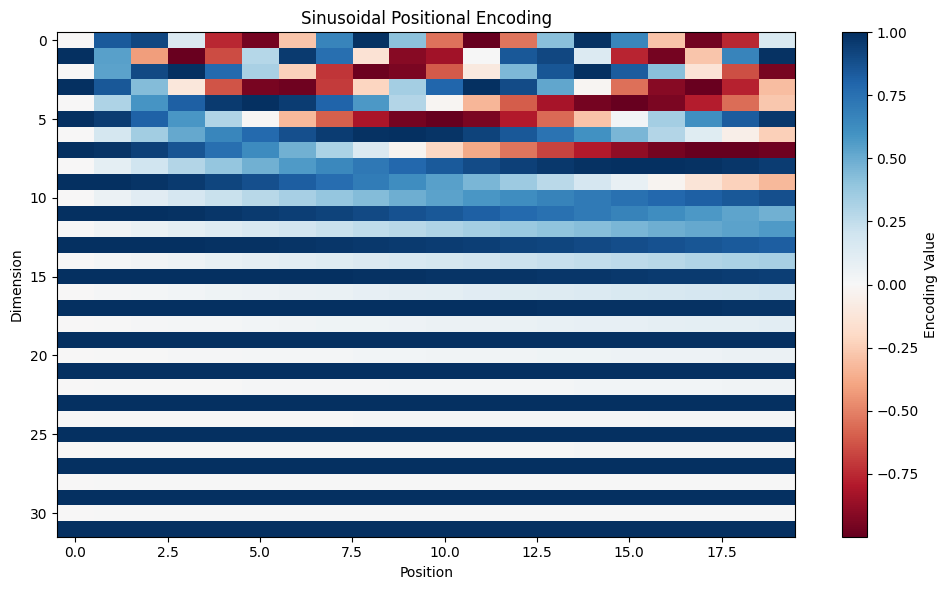

In [81]:
import matplotlib.pyplot as plt

d_model = 32
max_len = 20

pos_encoder = PositionalEncodingModule(d_model=d_model, max_len=max_len)
pe_matrix = pos_encoder.positional_embedding.squeeze().cpu().numpy()

plt.figure(figsize=(10, 6))
im = plt.imshow(pe_matrix.T, cmap='RdBu', aspect='auto')

plt.colorbar(im, label='Encoding Value')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Sinusoidal Positional Encoding')

plt.tight_layout()
plt.show()

### 2.2. Multihead Attention

Now let's build a class for the multihead attention module. We will implement the standard scaled dot-product attention that has the following formula (generated by Gemini):

$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V $$


One thing to note here is since our dataset isn't very big, having four heads with the same dimension as the model isn't very smart as it would increase the number of parameters and we might overfit, so we should take smaller dimension for d_k (our matrix dimensions). After performing some research apparently one common way to implement multihead attentions with a dimension lower than the model is to split the input tensors of the module and give each portion to a different head, this way we save some parameters and force the attention layer to learn different features as opposed to the case where if we gave it a full transformed features set (that way different heads might've learned the same thing as they had access to all the input but this way they need to learn the features from a local section and they will probably learn different aspects, eliminating the chance of redundancy)

In [71]:
import math

class MultiheadAttention(nn.Module):
    def __init__(self, N_heads, d_model, d_k, is_masked=True):
        super().__init__()
        self.N_heads = N_heads
        self.d_k = d_k
        self.d_model = d_model
        self.is_masked = is_masked

        self.Q_linear_layer = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )
        self.K_linear_layer = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )
        self.V_linear_layer = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )

        self.final_linear_layer = nn.Linear(
            in_features=d_model,
            out_features=d_model
        )

    def forward(self, x):
        batch_size, sequence_len, _ = x.shape
        
        Q = self.Q_linear_layer(x)
        Q = Q.view(batch_size, sequence_len, self.N_heads, self.d_k)
        Q = Q.transpose(1, 2)
        
        K = self.K_linear_layer(x)
        K = K.view(batch_size, sequence_len, self.N_heads, self.d_k)
        K = K.transpose(1, 2)
        
        V = self.V_linear_layer(x)
        V = V.view(batch_size, sequence_len, self.N_heads, self.d_k)
        V = V.transpose(1, 2)

        triangular_matrix = torch.ones(sequence_len, sequence_len).tril()
        tokens_to_remove = triangular_matrix == 0
        mask = torch.zeros(sequence_len, sequence_len)
        mask = mask.masked_fill(tokens_to_remove, float("-inf"))

        K_t = K.transpose(2, 3)
        scores = (Q @ K_t) / (math.sqrt(self.d_k))
        softmax_input = scores
        if self.is_masked:
            softmax_input = scores + mask

        scores = nn.functional.softmax(
            input=softmax_input,
            dim=3
        )
        attention_output = scores @ V
        attention_output = attention_output.transpose(1, 2).contiguous()
        concatenated_output = attention_output.view(batch_size, sequence_len, self.d_model)
        output = self.final_linear_layer(concatenated_output)

        return output

### 2.3. The Transformer

Now let's make a transformer class which will be used as the main component in our model.

In [72]:
model_hyperparameters = {
    "N_layers" : 3,
    "N_attention_heads" : 4,
    "d_model" : 64,
    "d_feed_forward" : 256,
    "max_len" : 20,
    "dropout" : 0.1,
    "vocab_size" : vocab_size,
    "attention_dimension" : 16
}


class TransformerBlock(nn.Module):
    def __init__(self, hyperparameters):
        super().__init__()

        self.masked_attention = MultiheadAttention(
            N_heads=hyperparameters["N_attention_heads"],
            d_model=hyperparameters["d_model"],
            d_k=hyperparameters["attention_dimension"],
            is_masked=True
        )

        self.attention_normalization = nn.LayerNorm(
            normalized_shape=hyperparameters["d_model"]
        )

        self.feed_forward = nn.Sequential(
            nn.Linear(
                in_features=hyperparameters["d_model"],
                out_features=hyperparameters["d_feed_forward"]
            ),

            nn.ReLU(),

            nn.Linear(
                in_features=hyperparameters["d_feed_forward"],
                out_features=hyperparameters["d_model"]
            )
        )

        self.feed_forward_normalization = nn.LayerNorm(
            normalized_shape=hyperparameters["d_model"]
        )

    def forward(self, x):
        normalization_input = self.attention_normalization(x)
        attention_output = x + self.masked_attention(normalization_input)
        
        feed_forward_normalized_input = self.feed_forward_normalization(attention_output)
        feed_forward_output = attention_output + self.feed_forward(feed_forward_normalized_input)

        return feed_forward_output
  

### 2.4. Defining the Model

Finally let's define the entire model.

In [73]:
  
class LLM(nn.Module):
    def __init__(self, hyperparameters):
        super().__init__()
        self.hyperparameters = hyperparameters
        self.token_embedding = nn.Embedding(
            num_embeddings=hyperparameters["vocab_size"],
            embedding_dim=hyperparameters["d_model"]
        )

        self.positional_encoding = PositionalEncodingModule(
            d_model=hyperparameters["d_model"],
            max_len=hyperparameters["max_len"]
        )

        self.TransformerBlockList = []
        for _ in range(hyperparameters["N_layers"]):
            self.TransformerBlockList.append(TransformerBlock(
                    hyperparameters=hyperparameters
                )
            )
        self.TransformerBlockList = nn.ModuleList(self.TransformerBlockList)

        self.linear = nn.Linear(
            in_features=hyperparameters["d_model"],
            out_features=hyperparameters["vocab_size"]
        )

    def forward(self, x):
        embeddings = self.token_embedding(x)
        transformer_input = self.positional_encoding(embeddings)
        
        transformer_output = transformer_input
        for transformer_block in self.TransformerBlockList:
            transformer_output = transformer_block(transformer_output)

        logits = self.linear(transformer_output)

        return logits

## 3. Training

### 3.1. Creating the Pytorch Dataset

To train the model we first have to create a costume pytorch dataset.

In [74]:
train_hyperparameters = {
    "epochs" : 3,
    "batch_size" : 256,
    "learning_rate" : 0.001,
    "optimizer" : "Adam",
    "validation_split" : 0.1,
    "gradient_clip" : 1,
    "loss" : "CrossEntropyLoss"
}

In [75]:
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from torch.utils.data import random_split

class NamesDataset(Dataset):
    def __init__(self, input_tensors, target_tensors):
        self.inputs = input_tensors
        self.targets = target_tensors

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = NamesDataset(input_sequence, output_sequence)

And now lets split the dataset!

In [76]:
total_size = len(dataset)
val_size = int(total_size * train_hyperparameters["validation_split"])
train_size = total_size - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = train_hyperparameters["batch_size"] 
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### 3.2. Initializing the Model

Now we will initialize the model.

In [77]:
device = torch.device("cpu")
print(f"Using device: {device}")

model = LLM(
    model_hyperparameters
).to(device)

pad_idx = char_to_int["<PAD>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(model.parameters(), lr=train_hyperparameters["learning_rate"])

Using device: cpu


### 3.3. Training Loop

Now let's define the training loop and train our model!

Total parameters: 153693
Epoch [1/3] | Train Loss: 2.2421 | Val Loss: 2.1507 | Time: 15.70s
Epoch [2/3] | Train Loss: 2.1037 | Val Loss: 2.0791 | Time: 15.49s
Epoch [3/3] | Train Loss: 2.0636 | Val Loss: 2.0517 | Time: 15.15s


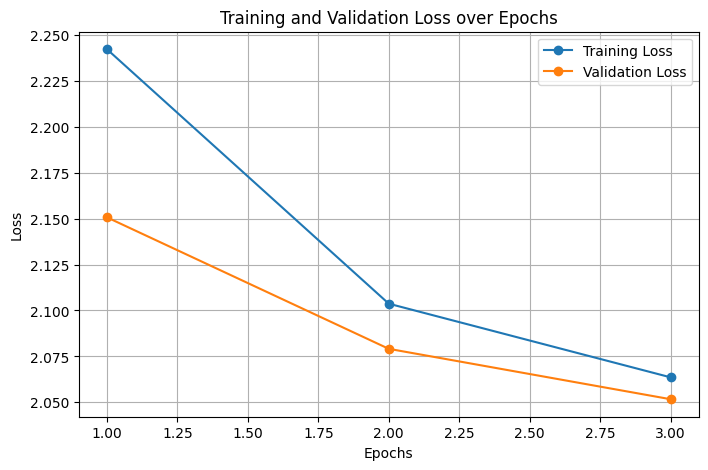

In [78]:
import time
import matplotlib.pyplot as plt
import torch

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")

train_losses = []
val_losses = []
num_epochs = train_hyperparameters["epochs"]

for epoch in range(num_epochs):
    start_time = time.time()
    
    model.train()
    total_train_loss = 0
    for inputs, targets in train_dataloader:
        optimizer.zero_grad()
        outputs = model(inputs)
        
        loss = criterion(outputs.view(-1, model_hyperparameters["vocab_size"]), targets.view(-1))
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_hyperparameters["gradient_clip"])
        optimizer.step()
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            outputs = model(inputs)
            loss = criterion(outputs.view(-1, model_hyperparameters["vocab_size"]), targets.view(-1))
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)
    
    epoch_time = time.time() - start_time
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_time:.2f}s")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### 3.4. Sampling

Now that we have trained the model, we need a method to sample form it (convert the logits to probability and then sample from them). We will use greedy decoding and temperature sampling.

In [79]:
def generate_name(model, start_str, char_to_idx, idx_to_char, max_len=20, temperature=1.0):
    model.eval()
    
    chars = list(start_str.lower())
    input_indices = [char_to_idx['<SOS>']] + [char_to_idx.get(c, char_to_idx['<PAD>']) for c in chars]
    input_tensor = torch.tensor(input_indices).unsqueeze(0) 
    
    with torch.no_grad():
        for _ in range(max_len - len(input_indices)):
            outputs = model(input_tensor) 
            next_token_logits = outputs[0, -1, :] 
            
            if temperature == 0.0:
                next_token = torch.argmax(next_token_logits).item()
            else:
                scaled_logits = next_token_logits / temperature
                probs = torch.nn.functional.softmax(scaled_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1).item()
                
            if next_token == char_to_idx['<EOS>']:
                break
                
            input_tensor = torch.cat([input_tensor, torch.tensor([[next_token]])], dim=1)
            
    generated_indices = input_tensor[0].tolist()
    generated_str = "".join([idx_to_char[idx] for idx in generated_indices if idx not in (char_to_idx['<SOS>'], char_to_idx['<EOS>'], char_to_idx['<PAD>'])])
    
    return generated_str

### 3.5. Testing the Model

And finally, let's produce some outputs to visually asses the model.

In [82]:
prompts = ['a', 'mar', 'li', 'c']
temperatures = [0.0, 0.5, 1.0]

names = set(names)

for prompt in prompts:
    for temp in temperatures:
        print(f"------------- Prompt: {prompt}, Temperature: {temp}")
        for i in range(5):
            name = generate_name(model, prompt, char_to_int, int_to_char, max_len=20, temperature=temp)
            
            is_real = "Yes" if name in names else "No"
            print(f"  {i+1}. {name} (In Dataset? {is_real})")

------------- Prompt: a, Temperature: 0.0
  1. alisa (In Dataset? Yes)
  2. alisa (In Dataset? Yes)
  3. alisa (In Dataset? Yes)
  4. alisa (In Dataset? Yes)
  5. alisa (In Dataset? Yes)
------------- Prompt: a, Temperature: 0.5
  1. allisa (In Dataset? Yes)
  2. aliliah (In Dataset? No)
  3. abari (In Dataset? No)
  4. alexia (In Dataset? Yes)
  5. allean (In Dataset? Yes)
------------- Prompt: a, Temperature: 1.0
  1. aimaria (In Dataset? No)
  2. andria (In Dataset? Yes)
  3. alynah (In Dataset? Yes)
  4. aschi (In Dataset? No)
  5. arniss (In Dataset? No)
------------- Prompt: mar, Temperature: 0.0
  1. marianna (In Dataset? Yes)
  2. marianna (In Dataset? Yes)
  3. marianna (In Dataset? Yes)
  4. marianna (In Dataset? Yes)
  5. marianna (In Dataset? Yes)
------------- Prompt: mar, Temperature: 0.5
  1. markea (In Dataset? Yes)
  2. marika (In Dataset? Yes)
  3. mariana (In Dataset? Yes)
  4. marilyn (In Dataset? Yes)
  5. marylen (In Dataset? Yes)
------------- Prompt: mar, Temper